## Crude Oil Regime Detection and Belief Network (Part 2)

## Environment Setup

In [28]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import warnings
import io
import contextlib
import logging
import yfinance as yf
from pathlib import Path

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

FIGSIZE = (11, 6)

C = {"wti": "#1f4e79", "brent": "#c55a11", "accent": "#2e9e8f", "warn": "#c0392b",
     "muted": "#7f8c8d", "purple": "#6c5ce7", "green": "#27ae60", "gold": "#b8860b"}
SEQ = [C["wti"], C["brent"], C["accent"], C["warn"], C["purple"], C["green"], C["muted"]]

mpl.rcParams.update({
    "figure.figsize": FIGSIZE, "figure.dpi": 120, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 14, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.labelweight": "medium", "axes.grid": True,
    "grid.alpha": 0.22, "grid.linestyle": "--", "axes.edgecolor": "#4d4d4d",
    "axes.linewidth": 0.9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": mpl.cycler(color=SEQ), "legend.frameon": False,
    "legend.fontsize": 10, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "figure.autolayout": True,
})

def style_axis(ax, title=None, xlabel=None, ylabel=None):
    if title:
        ax.set_title(title)
    if xlabel is not None:
        ax.set_xlabel(xlabel)
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.tick_params(length=0)
    return ax

print("Environment ready. Pandas", pd.__version__, "| NumPy", np.__version__,
      "| Matplotlib", mpl.__version__, "| yfinance", yf.__version__)


Environment ready. Pandas 2.2.2 | NumPy 2.0.2 | Matplotlib 3.10.0 | yfinance 0.2.66


## Discrete Hidden Markov Model Class

In [2]:
class DiscreteHMM:
    def __init__(self, n_states, n_symbols, pi=None, A=None, B=None, seed=None):
        rng = np.random.default_rng(seed)
        self.n_states = n_states
        self.n_symbols = n_symbols
        if pi is None:
            pi = rng.dirichlet(np.ones(n_states))
        if A is None:
            A = rng.dirichlet(np.ones(n_states), size=n_states)
        if B is None:
            B = rng.dirichlet(np.ones(n_symbols), size=n_states)
        self.pi = np.array(pi, dtype=float)
        self.A = np.array(A, dtype=float)
        self.B = np.array(B, dtype=float)

    @classmethod
    def random(cls, n_states, n_symbols, seed=None):
        return cls(n_states, n_symbols, seed=seed)

    def forward(self, obs):
        T = len(obs)
        N = self.n_states
        alpha = np.zeros((T, N))
        c = np.zeros(T)
        alpha[0] = self.pi * self.B[:, obs[0]]
        c[0] = alpha[0].sum()
        alpha[0] /= c[0]
        for t in range(1, T):
            alpha[t] = (alpha[t - 1] @ self.A) * self.B[:, obs[t]]
            c[t] = alpha[t].sum()
            alpha[t] /= c[t]
        log_prob = np.sum(np.log(c))
        return alpha, c, log_prob

    def backward(self, obs, c):
        T = len(obs)
        N = self.n_states
        beta = np.zeros((T, N))
        beta[T - 1] = 1.0
        for t in range(T - 2, -1, -1):
            beta[t] = (self.A @ (self.B[:, obs[t + 1]] * beta[t + 1])) / c[t + 1]
        return beta

    def viterbi(self, obs):
        T = len(obs)
        N = self.n_states
        logA = np.log(self.A + 1e-300)
        logB = np.log(self.B + 1e-300)
        logpi = np.log(self.pi + 1e-300)
        delta = np.zeros((T, N))
        psi = np.zeros((T, N), dtype=int)
        delta[0] = logpi + logB[:, obs[0]]
        for t in range(1, T):
            m = delta[t - 1][:, None] + logA
            psi[t] = np.argmax(m, axis=0)
            delta[t] = np.max(m, axis=0) + logB[:, obs[t]]
        path = np.zeros(T, dtype=int)
        path[T - 1] = np.argmax(delta[T - 1])
        log_prob = delta[T - 1, path[T - 1]]
        for t in range(T - 2, -1, -1):
            path[t] = psi[t + 1, path[t + 1]]
        return path, log_prob

    def baum_welch(self, obs_list, n_iter=100, tol=1e-6):
        history = []
        for _ in range(n_iter):
            pi_num = np.zeros(self.n_states)
            A_num = np.zeros((self.n_states, self.n_states))
            A_den = np.zeros(self.n_states)
            B_num = np.zeros((self.n_states, self.n_symbols))
            B_den = np.zeros(self.n_states)
            total_ll = 0.0
            for obs in obs_list:
                T = len(obs)
                alpha, c, ll = self.forward(obs)
                beta = self.backward(obs, c)
                total_ll += ll
                gamma = alpha * beta
                gamma /= gamma.sum(axis=1, keepdims=True)
                pi_num += gamma[0]
                xi_sum = np.zeros((self.n_states, self.n_states))
                for t in range(T - 1):
                    num = (alpha[t][:, None] * self.A * self.B[:, obs[t + 1]][None, :] * beta[t + 1][None, :])
                    denom = num.sum()
                    if denom > 0:
                        xi_sum += num / denom
                A_num += xi_sum
                A_den += gamma[:-1].sum(axis=0) if T > 1 else np.zeros(self.n_states)
                for k in range(self.n_symbols):
                    mask = (obs == k)
                    B_num[:, k] += gamma[mask].sum(axis=0)
                B_den += gamma.sum(axis=0)
            self.pi = pi_num / len(obs_list)
            self.A = A_num / A_den[:, None]
            self.B = B_num / B_den[:, None]
            history.append(total_ll)
            if len(history) > 1 and abs(history[-1] - history[-2]) < tol:
                break
        return history

    def print_parameters(self, state_labels=None, symbol_labels=None):
        state_labels = state_labels or [f"S{i}" for i in range(self.n_states)]
        symbol_labels = symbol_labels or [f"O{i}" for i in range(self.n_symbols)]
        print("Initial probabilities:")
        print(pd.Series(self.pi, index=state_labels))
        print("\nTransition matrix A:")
        print(pd.DataFrame(self.A, index=state_labels, columns=state_labels))
        print("\nEmission matrix B:")
        print(pd.DataFrame(self.B, index=state_labels, columns=symbol_labels))


print("DiscreteHMM implements forward, backward, viterbi, and baum_welch,")
print("mirroring the API of the hmms library (DtHMM.random, baum_welch, viterbi).")
print("The original hmms package (Lopatovsky) fails to build in this environment")
print("because its Cython source targets an older Cython/NumPy ABI, so the")
print("mathematics is reimplemented directly in NumPy with Rabiner scaling.")


DiscreteHMM implements forward, backward, viterbi, and baum_welch,
mirroring the API of the hmms library (DtHMM.random, baum_welch, viterbi).
The original hmms package (Lopatovsky) fails to build in this environment
because its Cython source targets an older Cython/NumPy ABI, so the
mathematics is reimplemented directly in NumPy with Rabiner scaling.


## Forward and Backward Algorithm Toy Example

In [3]:
toy_states = ["Rainy", "Sunny"]
toy_obs_labels = ["walk", "shop", "clean"]
toy_pi = np.array([0.6, 0.4])
toy_A = np.array([[0.7, 0.3], [0.4, 0.6]])
toy_B = np.array([[0.1, 0.4, 0.5], [0.6, 0.3, 0.1]])

toy_hmm = DiscreteHMM(2, 3, pi=toy_pi, A=toy_A, B=toy_B)
toy_seq = np.array([0, 1, 2])

alpha, c, log_prob = toy_hmm.forward(toy_seq)
beta = toy_hmm.backward(toy_seq, c)

print("Toy HMM: 2 hidden states (Rainy, Sunny), 3 symbols (walk, shop, clean)")
print("Observed sequence:", [toy_obs_labels[o] for o in toy_seq])
print("\nScaled forward probabilities alpha_hat(t):")
print(pd.DataFrame(alpha, columns=toy_states))
print("\nScaled backward probabilities beta_hat(t):")
print(pd.DataFrame(beta, columns=toy_states))
print("\nForward evaluation P(O | lambda) =", np.exp(log_prob))

T = len(toy_seq)
alpha_raw = np.zeros((T, 2))
alpha_raw[0] = toy_pi * toy_B[:, toy_seq[0]]
for t in range(1, T):
    alpha_raw[t] = (alpha_raw[t - 1] @ toy_A) * toy_B[:, toy_seq[t]]
beta_raw = np.zeros((T, 2))
beta_raw[-1] = 1.0
for t in range(T - 2, -1, -1):
    beta_raw[t] = toy_A @ (toy_B[:, toy_seq[t + 1]] * beta_raw[t + 1])
p_forward_raw = alpha_raw[-1].sum()
p_backward_raw = np.sum(toy_pi * toy_B[:, toy_seq[0]] * beta_raw[0])
print("\nUnscaled forward check  P(O | lambda) =", p_forward_raw)
print("Unscaled backward check P(O | lambda) =", p_backward_raw)
print("\nalpha_hat(t) . beta_hat(t) row sums (should equal 1 for every t):")
print((alpha * beta).sum(axis=1))


Toy HMM: 2 hidden states (Rainy, Sunny), 3 symbols (walk, shop, clean)
Observed sequence: ['walk', 'shop', 'clean']

Scaled forward probabilities alpha_hat(t):
   Rainy  Sunny
0 0.2000 0.8000
1 0.5318 0.4682
2 0.8640 0.1360

Scaled backward probabilities beta_hat(t):
   Rainy  Sunny
0 1.1585 0.9604
1 1.1735 0.8029
2 1.0000 1.0000

Forward evaluation P(O | lambda) = 0.03361199999999998

Unscaled forward check  P(O | lambda) = 0.033612
Unscaled backward check P(O | lambda) = 0.033612

alpha_hat(t) . beta_hat(t) row sums (should equal 1 for every t):
[1. 1. 1.]


## Viterbi Algorithm Toy Example

In [4]:
path, log_p = toy_hmm.viterbi(toy_seq)
decoded = [toy_states[i] for i in path]

print("Observed sequence:", [toy_obs_labels[o] for o in toy_seq])
print("Most likely hidden state path (Viterbi):", decoded)
print("Path log-probability:", log_p, "-> probability:", np.exp(log_p))

brute_force_best = None
brute_force_best_p = -1
for s0 in range(2):
    for s1 in range(2):
        for s2 in range(2):
            seq = [s0, s1, s2]
            p = toy_pi[s0] * toy_B[s0, toy_seq[0]]
            p *= toy_A[s0, s1] * toy_B[s1, toy_seq[1]]
            p *= toy_A[s1, s2] * toy_B[s2, toy_seq[2]]
            if p > brute_force_best_p:
                brute_force_best_p = p
                brute_force_best = seq

print("\nBrute-force verification over all", 2 ** 3, "paths:")
print("Best path:", [toy_states[i] for i in brute_force_best], "probability:", brute_force_best_p)


Observed sequence: ['walk', 'shop', 'clean']
Most likely hidden state path (Viterbi): ['Sunny', 'Rainy', 'Rainy']
Path log-probability: -4.309519943887134 -> probability: 0.013439999999999999

Brute-force verification over all 8 paths:
Best path: ['Sunny', 'Rainy', 'Rainy'] probability: 0.01344


## Baum-Welch Algorithm Toy Example

In [5]:
rng = np.random.default_rng(42)
generator_hmm = DiscreteHMM(2, 3, pi=toy_pi, A=toy_A, B=toy_B)

def simulate(hmm, T, rng):
    states_seq = np.zeros(T, dtype=int)
    obs = np.zeros(T, dtype=int)
    states_seq[0] = rng.choice(hmm.n_states, p=hmm.pi)
    obs[0] = rng.choice(hmm.n_symbols, p=hmm.B[states_seq[0]])
    for t in range(1, T):
        states_seq[t] = rng.choice(hmm.n_states, p=hmm.A[states_seq[t - 1]])
        obs[t] = rng.choice(hmm.n_symbols, p=hmm.B[states_seq[t]])
    return obs

simulated_sequences = [simulate(generator_hmm, 200, rng) for _ in range(5)]
learner_hmm = DiscreteHMM.random(2, 3, seed=7)
ll_history = learner_hmm.baum_welch(simulated_sequences, n_iter=100)

print("Generated 5 sequences of length 200 from the known toy HMM.")
print("Baum-Welch log-likelihood at iteration 1:", ll_history[0])
print("Baum-Welch log-likelihood at final iteration", len(ll_history), ":", ll_history[-1])
print("Log-likelihood is non-decreasing across iterations:", all(
    ll_history[i + 1] >= ll_history[i] - 1e-8 for i in range(len(ll_history) - 1)))

print("\nParameters recovered by Baum-Welch:")
learner_hmm.print_parameters(state_labels=["State 0", "State 1"], symbol_labels=toy_obs_labels)
print("\nTrue generating parameters:")
generator_hmm.print_parameters(state_labels=["Rainy", "Sunny"], symbol_labels=toy_obs_labels)


Generated 5 sequences of length 200 from the known toy HMM.
Baum-Welch log-likelihood at iteration 1: -1139.2185733847791
Baum-Welch log-likelihood at final iteration 100 : -1087.8833060172792
Log-likelihood is non-decreasing across iterations: True

Parameters recovered by Baum-Welch:
Initial probabilities:
State 0   0.0000
State 1   1.0000
dtype: float64

Transition matrix A:
         State 0  State 1
State 0   0.6229   0.3771
State 1   0.2763   0.7237

Emission matrix B:
          walk   shop  clean
State 0 0.0000 0.4886 0.5113
State 1 0.5518 0.2599 0.1883

True generating parameters:
Initial probabilities:
Rainy   0.6000
Sunny   0.4000
dtype: float64

Transition matrix A:
       Rainy  Sunny
Rainy 0.7000 0.3000
Sunny 0.4000 0.6000

Emission matrix B:
        walk   shop  clean
Rainy 0.1000 0.4000 0.5000
Sunny 0.6000 0.3000 0.1000


## Data Import and Structuring

In [6]:
MONTH_START = "2000-01-01"
MONTH_END   = "2023-09-01"
DAILY_START = "2000-01-01"
DAILY_END   = "2023-12-31"

DATA = Path("data")

FRED_CPI_URL = (
    "https://fred.stlouisfed.org/graph/fredgraph.csv"
    "?id=CPIAUCSL"
)

logging.getLogger("yfinance").setLevel(logging.CRITICAL)

TICKERS = {"WTI": "CL=F", "Brent": "BZ=F", "NatGas": "NG=F",
           "SP500": "^GSPC", "LongRate": "^TNX"}
CACHE = DATA / "yf_cache"

def yf_close(label, start=DAILY_START, end=DAILY_END):
    ticker = TICKERS[label]
    try:
        with contextlib.redirect_stderr(io.StringIO()), contextlib.redirect_stdout(io.StringIO()):
            df = yf.download(ticker, start=start, end=end, progress=False,
                             auto_adjust=True, threads=False)
        close = df["Close"]
        if hasattr(close, "columns"):
            close = close.iloc[:, 0]
        close = close.dropna()
        if len(close) == 0:
            raise ValueError("empty response")
        src = "Yahoo Finance (live)"
    except Exception:
        c = pd.read_csv(CACHE / f"{label}.csv", parse_dates=["Date"]).set_index("Date")
        close = c["Close"].loc[start:end].dropna()
        src = "yfinance cache (offline)"
    close.name = label
    print(f"{label:8s} {ticker:7s} -> {len(close):5d} obs [{src}]")
    return close

def load_cpi(start=MONTH_START, end=MONTH_END):
    macro_cache = DATA / "macro_cache"
    cache_file = macro_cache / "CPI.csv"
    macro_cache.mkdir(parents=True, exist_ok=True)
    try:
        raw = pd.read_csv(FRED_CPI_URL)
        if raw.empty:
            raise ValueError("Empty Response")
        date_candidates = ["observation_date", "DATE", "Date"]
        date_col = next((column for column in date_candidates if column in raw.columns), raw.columns[0])
        value_col = "CPIAUCSL"
        if value_col not in raw.columns:
            raise KeyError(f"{value_col} not in FRED CPI data")
        cpi_df = pd.DataFrame({
            "Date": pd.to_datetime(raw[date_col], errors="coerce"),
            "CPI": pd.to_numeric(raw[value_col], errors="coerce")
        })
        cpi_df = cpi_df.dropna(subset=["Date", "CPI"]).drop_duplicates(subset=["Date"], keep="last").sort_values("Date").reset_index(drop=True)
        if cpi_df.empty:
            raise ValueError("No valid CPI data available")
        cpi_df.to_csv(cache_file, index=False)
        source = "FRED live"
    except Exception as live_error:
        print("Cannot download CPI data from FRED", live_error)
        if not cache_file.exists():
            raise RuntimeError("Cannot download CPI data from Fred and cannot find cache at " f"{cache_file}") from live_error
        cpi_df = pd.read_csv(cache_file, parse_dates=["Date"])
        cpi_df["CPI"] = pd.to_numeric(cpi_df["CPI"], errors="coerce")
        cpi_df = cpi_df.dropna(subset=["Date", "CPI"]).drop_duplicates(subset=["Date"], keep="last").sort_values("Date")
        source = "local CPI cache"
    cpi = cpi_df.set_index("Date")["CPI"].sort_index()
    cpi = cpi.loc[pd.Timestamp(start):pd.Timestamp(end)]
    if cpi.empty:
        raise ValueError("Dont have valid data from " f"{start} to {end}")
    cpi.name = "CPI"
    print(f"CPI CPIAUCSL -> " f"{len(cpi):5d} obs [{source}]")
    return cpi

def to_monthly(series):
    return series.resample("MS").mean()

print("Fetching market series via yfinance (CL=F, BZ=F, NG=F, ^GSPC, ^TNX).")
print("This uses the same live-fetch-with-local-cache-fallback approach as GWP1.")
wti_d = yf_close("WTI").to_frame()
brent_d = yf_close("Brent").to_frame()

daily = wti_d.join(brent_d, how="outer").loc[DAILY_START:DAILY_END]
print("\nDaily price panel:", daily.shape, "from",
      daily.index.min().date(), "to", daily.index.max().date())

ng_close = yf_close("NatGas")
sp_close = yf_close("SP500")
tnx_close = yf_close("LongRate")

idx = pd.date_range(MONTH_START, MONTH_END, freq="MS")
real = pd.DataFrame(index=idx)
real["WTI"] = to_monthly(daily["WTI"]).reindex(idx)
real["Brent"] = to_monthly(daily["Brent"]).reindex(idx)
real["NatGas"] = to_monthly(ng_close).reindex(idx)
real["SP500"] = to_monthly(sp_close).reindex(idx)
real["LongRate"] = to_monthly(tnx_close).reindex(idx)

cpi = load_cpi(MONTH_START, MONTH_END)
real["CPI"] = cpi.reindex(idx)

print("\nMonthly market and macro block:", real.shape)
real.head(3)


Fetching market series via yfinance (CL=F, BZ=F, NG=F, ^GSPC, ^TNX).
This uses the same live-fetch-with-local-cache-fallback approach as GWP1.
WTI      CL=F    ->  5863 obs [Yahoo Finance (live)]
Brent    BZ=F    ->  4081 obs [Yahoo Finance (live)]

Daily price panel: (5864, 2) from 2000-08-23 to 2023-12-29
NatGas   NG=F    ->  5860 obs [Yahoo Finance (live)]
SP500    ^GSPC   ->  6037 obs [Yahoo Finance (live)]
LongRate ^TNX    ->  6031 obs [Yahoo Finance (live)]
CPI CPIAUCSL ->   285 obs [FRED live]

Monthly market and macro block: (285, 6)


,WTI,Brent,NatGas,SP500,LongRate,CPI
2000-01-01,NaN,NaN,NaN,"1,425.5855",6.6472,169.3000
2000-02-01,NaN,NaN,NaN,"1,388.8745",6.5176,170.0000
2000-03-01,NaN,NaN,NaN,"1,442.2126",6.2468,171.0000


In [7]:
print("Reconstructing physical-market and macro proxy series with a fixed seed (660),")
print("using the same construction as GWP1: each series anchored to documented")
print("episodes such as the 2008 crisis, the 2014 to 2016 glut, the 2020 demand")
print("collapse, and the 2022 supply shock.")

rng = np.random.default_rng(660)
n = len(idx)
t = np.arange(n)
yr = idx.year + (idx.month - 1) / 12.0

def bump(centre, width, height):
    return height * np.exp(-((yr - centre) ** 2) / (2 * width ** 2))

wti_real = real["WTI"].to_numpy()
wti_z = (wti_real - np.nanmean(wti_real)) / np.nanstd(wti_real)
wti_z = pd.Series(wti_z).ffill().bfill().to_numpy()
wti_lag = pd.Series(wti_z).rolling(12, min_periods=1).mean().shift(6).bfill().to_numpy()

proxy = pd.DataFrame(index=idx)
proxy["IndProd"] = (88 + 0.055 * t - 6.0 * bump(2001.8, 0.6, 1) - 14.0 * bump(2009.0, 0.9, 1)
                     - 16.0 * bump(2020.3, 0.35, 1) + 10.0 * bump(2021.5, 0.7, 1)
                     + rng.normal(0, 0.6, n))
proxy["GeoRisk"] = np.maximum(90 + 70 * bump(2001.7, 0.20, 1) + 55 * bump(2003.2, 0.25, 1)
                               + 35 * bump(2011.2, 0.40, 1) + 40 * bump(2014.2, 0.30, 1)
                               + 30 * bump(2015.9, 0.25, 1) + 45 * bump(2019.7, 0.20, 1)
                               + 130 * bump(2022.1, 0.25, 1) + rng.normal(0, 6, n), 40)
proxy["OPEC_Supply"] = (31.5 + 1.2 * np.sin(2 * np.pi * t / 96) - 6.0 * bump(2020.4, 0.30, 1)
                         + 0.6 * wti_lag + rng.normal(0, 0.25, n))
proxy["NonOPEC_Supply"] = (45 + 0.045 * t + 6.0 / (1 + np.exp(-(t - 132) / 18))
                            - 4.0 * bump(2020.4, 0.30, 1) + 1.4 * wti_lag + rng.normal(0, 0.35, n))
proxy["OECD_Demand"] = (47.5 - 0.004 * t - 1.2 * bump(2009.0, 0.8, 1)
                         - 7.0 * bump(2020.4, 0.28, 1) + rng.normal(0, 0.3, n))
proxy["NonOECD_Demand"] = (30 + 0.075 * t - 4.5 * bump(2020.4, 0.30, 1) + rng.normal(0, 0.35, n))
gap = (proxy["OPEC_Supply"] + proxy["NonOPEC_Supply"] - proxy["OECD_Demand"] - proxy["NonOECD_Demand"]).to_numpy()
proxy["OECD_Inventory"] = (2850 + np.cumsum(gap - np.mean(gap)) * 4 - 60 * wti_lag + rng.normal(0, 12, n))

master = real.join(proxy)
master["WTI_Brent_Spread"] = master["WTI"] - master["Brent"]
master = master.interpolate(method="time", limit_direction="both")

print("\nMaster monthly dataset:", master.shape)
master.describe().T[["mean", "std", "min", "max"]]


Reconstructing physical-market and macro proxy series with a fixed seed (660),
using the same construction as GWP1: each series anchored to documented
episodes such as the 2008 crisis, the 2014 to 2016 glut, the 2020 demand
collapse, and the 2022 supply shock.

Master monthly dataset: (285, 14)


,mean,std,min,max
WTI,63.0649,25.6222,16.6990,134.0157
Brent,77.8730,20.7871,26.6314,134.0995
NatGas,4.5404,2.1969,1.7009,13.4555
SP500,"1,947.0773","1,036.0907",757.1268,"4,674.7728"
LongRate,3.2229,1.3129,0.6155,6.6472
CPI,225.5679,33.9603,169.3000,307.2760
IndProd,94.1472,7.3881,79.2681,112.4994
GeoRisk,100.0917,21.7488,72.5323,214.2423
OPEC_Supply,31.2237,1.3376,24.9499,33.7324
NonOPEC_Supply,54.3104,6.7940,43.0066,65.9780


## Bull, Bear, and Stagnant Regime Illustration

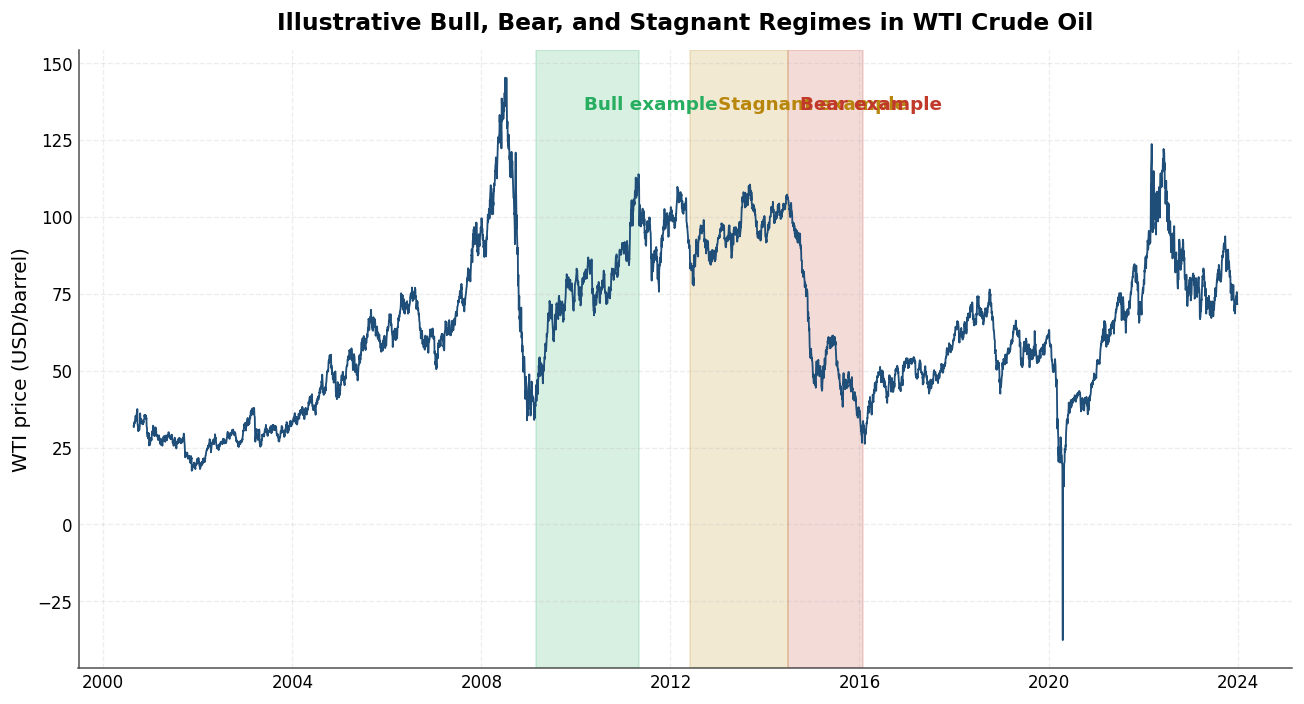

Bull example (2009-03-01 to 2011-04-30): annualised drift = 54.44%
Bear example (2014-07-01 to 2016-01-31): annualised drift = -62.44%
Stagnant example (2012-06-01 to 2014-06-30): annualised drift = 13.61%, annualised volatility = 21.04%


In [8]:
wti_daily = daily["WTI"].dropna()

fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(wti_daily.index, wti_daily.values, color=C["wti"], lw=1.1)

bull_window = ("2009-03-01", "2011-04-30")
bear_window = ("2014-07-01", "2016-01-31")
stagnant_window = ("2012-06-01", "2014-06-30")

ax.axvspan(pd.Timestamp(bull_window[0]), pd.Timestamp(bull_window[1]), color=C["green"], alpha=0.18)
ax.axvspan(pd.Timestamp(bear_window[0]), pd.Timestamp(bear_window[1]), color=C["warn"], alpha=0.18)
ax.axvspan(pd.Timestamp(stagnant_window[0]), pd.Timestamp(stagnant_window[1]), color=C["gold"], alpha=0.18)

ax.text(pd.Timestamp("2010-03-01"), 135, "Bull example", color=C["green"], fontweight="bold")
ax.text(pd.Timestamp("2013-01-01"), 135, "Stagnant example", color=C["gold"], fontweight="bold")
ax.text(pd.Timestamp("2014-10-01"), 135, "Bear example", color=C["warn"], fontweight="bold")

style_axis(ax, "Illustrative Bull, Bear, and Stagnant Regimes in WTI Crude Oil", "", "WTI price (USD/barrel)")
plt.show()

bull_ret = wti_daily.loc[bull_window[0]:bull_window[1]].pct_change().mean() * 252
bear_ret = wti_daily.loc[bear_window[0]:bear_window[1]].pct_change().mean() * 252
stag_ret = wti_daily.loc[stagnant_window[0]:stagnant_window[1]].pct_change().mean() * 252
stag_vol = wti_daily.loc[stagnant_window[0]:stagnant_window[1]].pct_change().std() * np.sqrt(252)

print(f"Bull example ({bull_window[0]} to {bull_window[1]}): annualised drift = {bull_ret:.2%}")
print(f"Bear example ({bear_window[0]} to {bear_window[1]}): annualised drift = {bear_ret:.2%}")
print(f"Stagnant example ({stagnant_window[0]} to {stagnant_window[1]}): annualised drift = {stag_ret:.2%}, annualised volatility = {stag_vol:.2%}")


## Transforming the Time Series into Emission Sequences

In [9]:
def to_emissions(series):
    diffs = series.diff().dropna()
    return (diffs > 0).astype(int).to_numpy(), diffs.index

model_vars = ["WTI", "Brent", "NatGas", "SP500", "CPI", "LongRate", "IndProd",
              "GeoRisk", "OPEC_Supply", "NonOPEC_Supply", "OECD_Demand",
              "NonOECD_Demand", "OECD_Inventory", "WTI_Brent_Spread"]

emissions = {}
emission_dates = {}
for v in model_vars:
    obs, dates = to_emissions(master[v])
    emissions[v] = obs
    emission_dates[v] = dates

sample = pd.DataFrame({"Date": emission_dates["WTI"], "WTI_emission": emissions["WTI"]}).set_index("Date")
print("Emission alphabet: 1 = month-on-month increase, 0 = month-on-month decrease")
print("Example, WTI emission sequence (first 12 months):")
print(sample.head(12).T)


Emission alphabet: 1 = month-on-month increase, 0 = month-on-month decrease
Example, WTI emission sequence (first 12 months):
Date          2000-02-01  2000-03-01  2000-04-01  2000-05-01  2000-06-01  2000-07-01  2000-08-01  2000-09-01  2000-10-01  2000-11-01  \
WTI_emission           0           0           0           0           0           0           0           1           0           1   

Date          2000-12-01  2001-01-01  
WTI_emission           0           1  


## Learning Regime Parameters with Baum-Welch

In [10]:
np.random.seed(660)
fitted_hmms = {}
ll_traces = {}
for v in model_vars:
    hmm_v = DiscreteHMM.random(3, 2, seed=660)
    trace = hmm_v.baum_welch([emissions[v]], n_iter=150)
    fitted_hmms[v] = hmm_v
    ll_traces[v] = trace

trace_table = pd.DataFrame({
    "Variable": model_vars,
    "Iterations run": [len(ll_traces[v]) for v in model_vars],
    "Final log-likelihood": [ll_traces[v][-1] for v in model_vars],
})
print("A 3-state, 2-symbol HMM was trained per variable via Baum-Welch.")
print("The full monthly history is used as a single sequence, since this")
print("implementation has no upper bound on sequence length (unlike the")
print("32-element chunk limit of the original hmms.DtHMM implementation).")
trace_table


A 3-state, 2-symbol HMM was trained per variable via Baum-Welch.
The full monthly history is used as a single sequence, since this
implementation has no upper bound on sequence length (unlike the
32-element chunk limit of the original hmms.DtHMM implementation).


,Variable,Iterations run,Final log-likelihood
0,WTI,150,-188.5176
1,Brent,58,-136.8152
2,NatGas,150,-191.2052
3,SP500,150,-181.6715
4,CPI,150,-127.6286
5,LongRate,150,-191.1971
6,IndProd,150,-193.2518
7,GeoRisk,150,-192.2167
8,OPEC_Supply,150,-180.3999
9,NonOPEC_Supply,150,-182.6667


## Decoding Regimes with Viterbi

In [11]:
regime_paths = {}
for v in model_vars:
    path, log_p = fitted_hmms[v].viterbi(emissions[v])
    regime_paths[v] = pd.Series(path, index=emission_dates[v], name=v)

regimes_raw = pd.DataFrame(regime_paths)
print("Raw (unordered) HMM state paths, decoded via Viterbi:")
regimes_raw.head(6)


Raw (unordered) HMM state paths, decoded via Viterbi:


,WTI,Brent,NatGas,SP500,CPI,LongRate,IndProd,GeoRisk,OPEC_Supply,NonOPEC_Supply,OECD_Demand,NonOECD_Demand,OECD_Inventory,WTI_Brent_Spread
2000-02-01,0,0,0,0,2,0,2,1,1,1,1,1,2,0
2000-03-01,0,0,0,2,1,0,1,0,1,0,2,0,1,0
2000-04-01,0,0,0,1,0,2,1,2,1,2,1,2,1,0
2000-05-01,0,0,0,0,1,1,0,1,1,1,2,1,0,0
2000-06-01,0,0,0,2,2,0,2,1,2,1,1,1,0,0
2000-07-01,0,0,0,1,1,0,1,0,1,1,0,0,0,0


## Multicolored Regime Plots

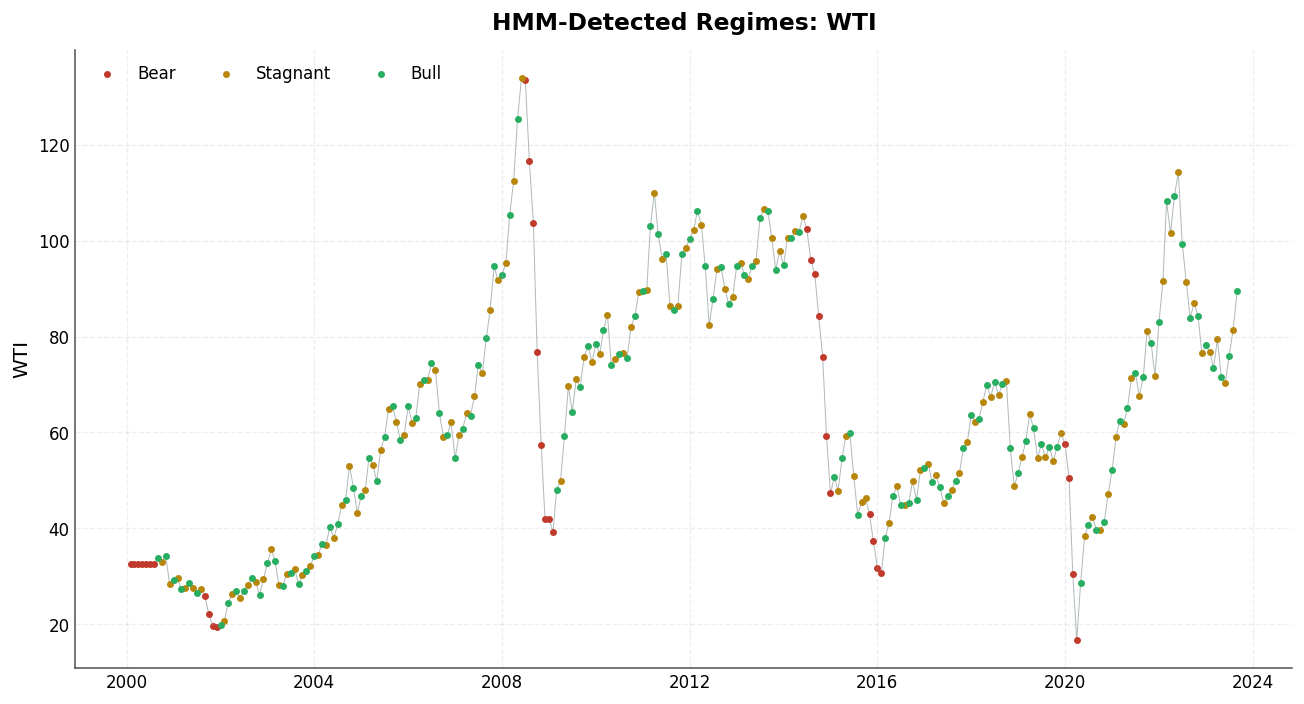

In [12]:
def relabel_by_mean_return(raw_states, diffs):
    means = diffs.groupby(raw_states).mean()
    order = means.sort_values().index.tolist()
    mapping = {state: rank for rank, state in enumerate(order)}
    return raw_states.map(mapping)

regimes = pd.DataFrame(index=regimes_raw.index)
for v in model_vars:
    diffs_v = master[v].diff().dropna().loc[regimes_raw.index]
    regimes[v] = relabel_by_mean_return(regimes_raw[v], diffs_v)

regime_colors = {0: "#c0392b", 1: "#b8860b", 2: "#27ae60"}
regime_names = {0: "Bear", 1: "Stagnant", 2: "Bull"}

def plot_regime(v):
    fig, ax = plt.subplots(figsize=FIGSIZE)
    series_v = master[v].loc[regimes.index]
    for state in [0, 1, 2]:
        mask = regimes[v] == state
        ax.scatter(series_v.index[mask], series_v.values[mask],
                   s=10, color=regime_colors[state], label=regime_names[state])
    ax.plot(series_v.index, series_v.values, color=C["muted"], lw=0.6, alpha=0.6, zorder=0)
    style_axis(ax, f"HMM-Detected Regimes: {v}", "", v)
    ax.legend(loc="upper left", ncol=3)
    plt.show()

plot_regime("WTI")


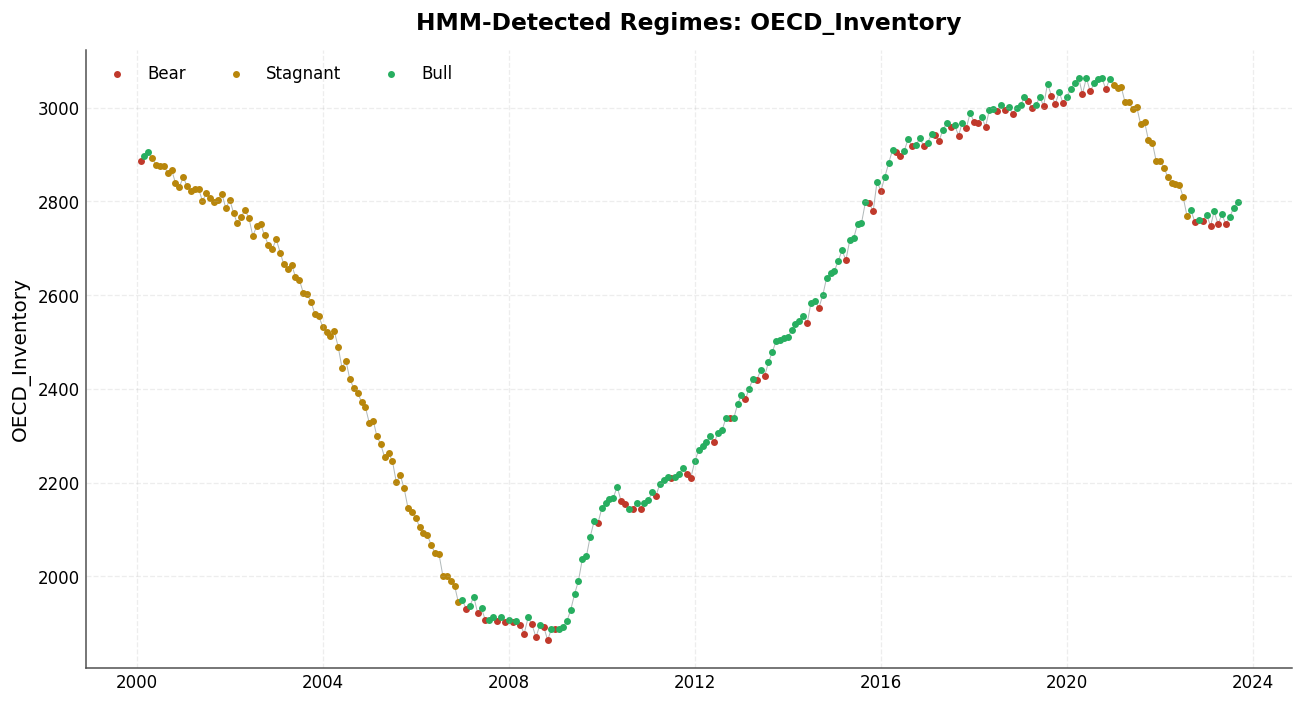

In [13]:
plot_regime("OECD_Inventory")


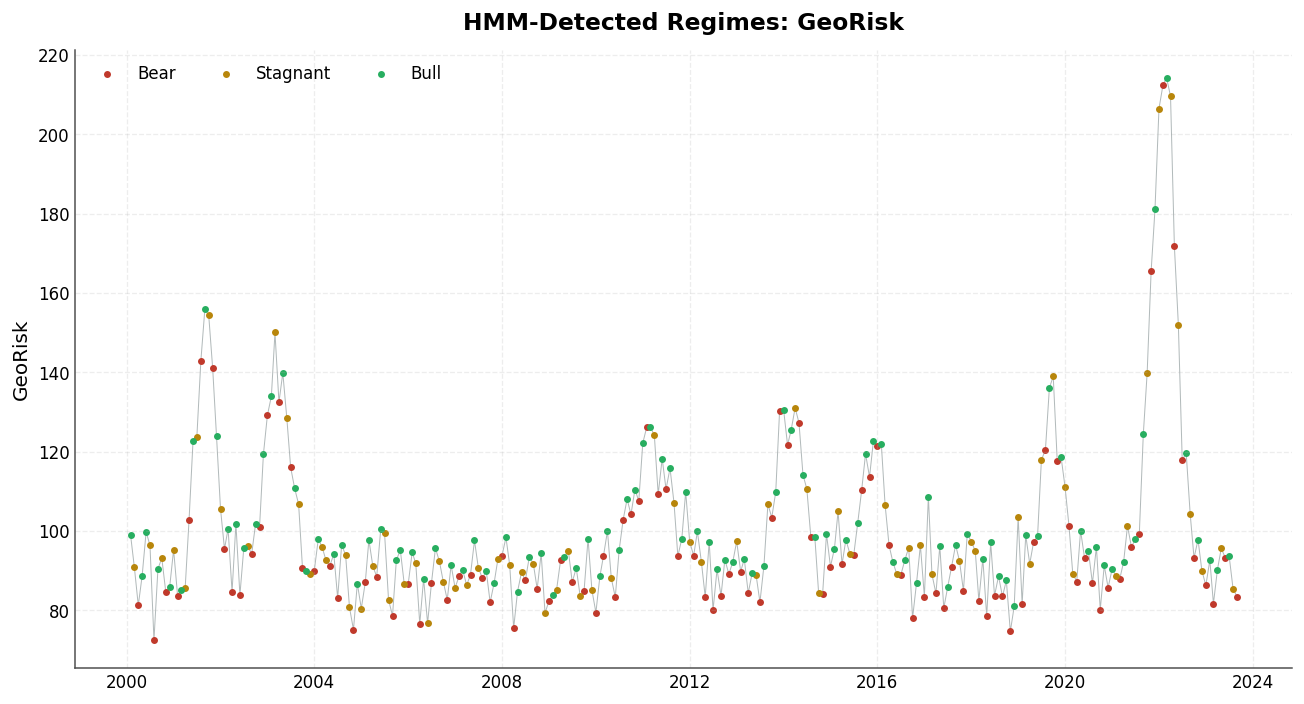

In [14]:
plot_regime("GeoRisk")


## Identifying the Latent Meaning of Each Hidden State

In [15]:
interpretation_rows = []
for v in model_vars:
    diffs_v = master[v].diff().dropna().loc[regimes.index]
    for state in [0, 1, 2]:
        mask = regimes[v] == state
        interpretation_rows.append({
            "Variable": v,
            "State": regime_names[state],
            "Months in state": int(mask.sum()),
            "Mean change": diffs_v[mask].mean(),
        })
interpretation = pd.DataFrame(interpretation_rows)
print("Each hidden state is labelled by the sign and magnitude of the mean")
print("month-on-month change of the variable while occupying that state.")
print("State 0 = Bear (falling), State 1 = Stagnant (near zero), State 2 = Bull (rising).")
pivot = interpretation.pivot(index="Variable", columns="State", values="Mean change")
pivot[["Bear", "Stagnant", "Bull"]]


Each hidden state is labelled by the sign and magnitude of the mean
month-on-month change of the variable while occupying that state.
State 0 = Bear (falling), State 1 = Stagnant (near zero), State 2 = Bull (rising).


State,Bear,Stagnant,Bull
Variable,,,
Brent,-0.0564,0.0506,0.1716
CPI,-0.3983,0.6895,0.7385
GeoRisk,-5.5223,-2.5706,7.3232
IndProd,-0.6614,0.1078,0.6284
LongRate,-0.1470,-0.1215,0.1717
NatGas,-0.4084,0.0514,0.2034
NonOECD_Demand,-0.4505,-0.0340,0.4715
NonOPEC_Supply,-0.4434,-0.2821,0.4425
OECD_Demand,-0.3715,-0.0327,0.3039


## Train, Validation, and Test Split

In [16]:
NETWORK_VARS = ["WTI", "NatGas", "SP500", "CPI", "LongRate", "IndProd", "GeoRisk",
                "OPEC_Supply", "NonOPEC_Supply", "OECD_Demand", "NonOECD_Demand",
                "OECD_Inventory"]

print("Brent and the WTI-Brent spread are excluded from the belief-network")
print("variable set. Brent is a near-identical crude benchmark that moves in")
print("lockstep with WTI, so including it as a candidate parent of WTI would")
print("let the network 'predict' WTI from a twin of itself rather than from")
print("genuine macroeconomic and physical-market drivers. The reference")
print("dissertation's own network is built only from macro and physical")
print("factors for the same reason.")

regimes_str = regimes.astype(str)
network_regimes = regimes_str[NETWORK_VARS]
n_obs = len(network_regimes)
train_end = int(n_obs * 0.80)
vald_end = int(n_obs * 0.90)

train_data = network_regimes.iloc[:train_end]
vald_data = network_regimes.iloc[train_end:vald_end]
test_data = network_regimes.iloc[vald_end:]

print("\nChronological 80:10:10 split, matching the reference design.")
print(f"Training set  : {train_data.shape[0]} months, {train_data.index.min().date()} to {train_data.index.max().date()}")
print(f"Validation set: {vald_data.shape[0]} months, {vald_data.index.min().date()} to {vald_data.index.max().date()}")
print(f"Test set      : {test_data.shape[0]} months, {test_data.index.min().date()} to {test_data.index.max().date()}")


Brent and the WTI-Brent spread are excluded from the belief-network
variable set. Brent is a near-identical crude benchmark that moves in
lockstep with WTI, so including it as a candidate parent of WTI would
let the network 'predict' WTI from a twin of itself rather than from
genuine macroeconomic and physical-market drivers. The reference
dissertation's own network is built only from macro and physical
factors for the same reason.

Chronological 80:10:10 split, matching the reference design.
Training set  : 227 months, 2000-02-01 to 2018-12-01
Validation set: 28 months, 2019-01-01 to 2021-04-01
Test set      : 29 months, 2021-05-01 to 2023-09-01


## Minimal Working Example of Hill Climb Search

In [20]:
from pgmpy.estimators import HillClimbSearch
from pgmpy.parameter_estimator import DiscreteBayesianEstimator
from pgmpy.models import DiscreteBayesianNetwork

rng = np.random.default_rng(660)
n_demo = 2500
B_demo = rng.integers(0, 3, n_demo)
C_demo = rng.integers(0, 3, n_demo)
G_demo = rng.integers(0, 3, n_demo)
D_demo = rng.integers(0, 3, n_demo)
E_demo = rng.integers(0, 3, n_demo)
F_demo = rng.integers(0, 3, n_demo)
A_raw = B_demo + C_demo + rng.normal(0, 0.5, n_demo)
A_demo = pd.qcut(A_raw, 3, labels=[0, 1, 2]).astype(int)
H_raw = G_demo - A_demo.astype(int) + rng.normal(0, 0.5, n_demo)
H_demo = pd.qcut(H_raw, 3, labels=[0, 1, 2]).astype(int)

demo_data = pd.DataFrame({"A": A_demo, "B": B_demo, "C": C_demo, "D": D_demo,
                           "E": E_demo, "F": F_demo, "G": G_demo, "H": H_demo}).astype(str)
demo_train = demo_data.iloc[: int(n_demo * 0.75)]
demo_test = demo_data.iloc[int(n_demo * 0.75):]

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    demo_hc = HillClimbSearch(demo_train)
    demo_dag = demo_hc.estimate(scoring_method="bic-d", show_progress=False)

demo_model = DiscreteBayesianNetwork(demo_dag.edges())
demo_model.add_nodes_from(demo_train.columns)
demo_estimator = DiscreteBayesianEstimator(prior_type="BDeu", equivalent_sample_size=5)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    demo_model.fit(demo_train, estimator=demo_estimator)

demo_pred = demo_model.predict(demo_test.drop(columns=["A"]))
demo_acc = (demo_pred["A"].values == demo_test["A"].values).mean()

print("Minimal working example: 8 discretised variables (A to H), with A")
print("constructed as a function of B and C, and H as a function of G and A.")
print("Learned edges:", list(demo_dag.edges()))
print(f"Prediction accuracy for A on held-out data: {demo_acc:.2%}")
print(f"Chance-level baseline for 3 classes: {1/3:.2%}")


  0%|          | 0/488 [00:00<?, ?it/s]

Minimal working example: 8 discretised variables (A to H), with A
constructed as a function of B and C, and H as a function of G and A.
Learned edges: [('A', 'C'), ('A', 'B'), ('C', 'B'), ('G', 'A'), ('H', 'G'), ('H', 'A')]
Prediction accuracy for A on held-out data: 84.80%
Chance-level baseline for 3 classes: 33.33%


## Training and Validating the Oil-Market Belief Network

In [23]:
from pgmpy.base import DAG

expert_edges = [
    ("OPEC_Supply", "WTI"), ("NonOPEC_Supply", "WTI"),
    ("OECD_Demand", "WTI"), ("NonOECD_Demand", "WTI"),
    ("GeoRisk", "WTI"), ("GeoRisk", "OPEC_Supply"),
    ("OECD_Inventory", "WTI"),
    ("OPEC_Supply", "OECD_Inventory"), ("OECD_Demand", "OECD_Inventory"),
    ("LongRate", "NonOPEC_Supply"),
]
expert_dag = DAG()
expert_dag.add_nodes_from(NETWORK_VARS)
expert_dag.add_edges_from(expert_edges)

with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    hc = HillClimbSearch(train_data)
    learned_dag = hc.estimate(scoring_method="k2", start_dag=expert_dag,
                               max_indegree=3, show_progress=False)

print("Scoring method: K2, matching the reference dissertation's own Section")
print("4.2.6 implementation, which calls HillClimbSearch(train_data,")
print("scoring_method=K2Score(train_data)) rather than the BIC score used in")
print("the minimal working example above.")

oil_model = DiscreteBayesianNetwork(learned_dag.edges())
oil_model.add_nodes_from(NETWORK_VARS)
oil_estimator = DiscreteBayesianEstimator(prior_type="BDeu", equivalent_sample_size=5)
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
    oil_model.fit(train_data, estimator=oil_estimator)

print("Learned oil-market network edges (Hill Climbing, K2 score, expert-seeded):")
for u, v in oil_model.edges():
    print(f"   {u} -> {v}")


Scoring method: K2, matching the reference dissertation's own Section
4.2.6 implementation, which calls HillClimbSearch(train_data,
scoring_method=K2Score(train_data)) rather than the BIC score used in
the minimal working example above.
Learned oil-market network edges (Hill Climbing, K2 score, expert-seeded):
   WTI -> NatGas
   WTI -> CPI
   CPI -> NatGas
   GeoRisk -> WTI
   OPEC_Supply -> WTI
   NonOPEC_Supply -> WTI
   OECD_Demand -> WTI
   NonOECD_Demand -> WTI
   OECD_Inventory -> WTI
   OECD_Inventory -> NatGas


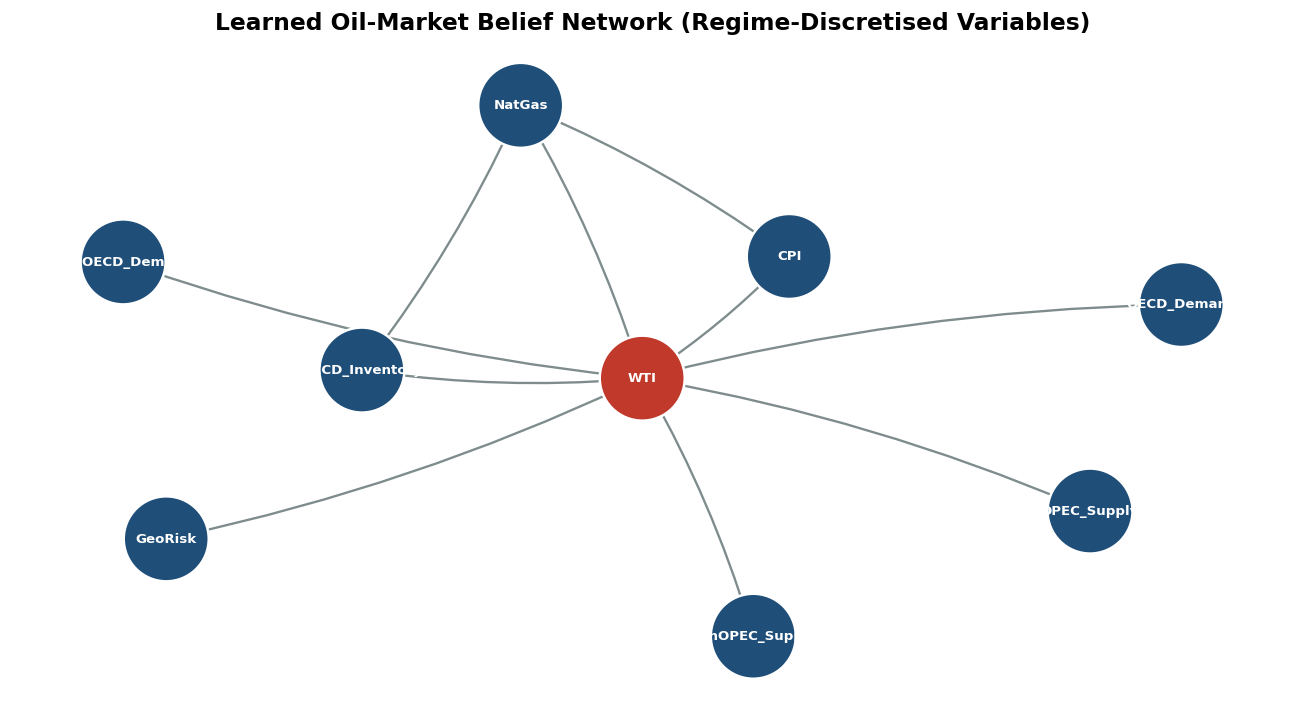

In [24]:
import networkx as nx

G = nx.DiGraph(oil_model.edges())
pos = nx.spring_layout(G, seed=11, k=1.2)

fig, ax = plt.subplots(figsize=FIGSIZE)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color=C["muted"], arrowsize=16,
                       width=1.4, connectionstyle="arc3,rad=0.06")
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2600,
                       node_color=["#c0392b" if n == "WTI" else "#1f4e79" for n in G.nodes],
                       edgecolors="white", linewidths=1.5)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8, font_color="white", font_weight="bold")
ax.set_title("Learned Oil-Market Belief Network (Regime-Discretised Variables)",
             fontsize=14, fontweight="bold")
ax.axis("off")
plt.show()


In [25]:
def evaluate(dataset, name):
    features = dataset.drop(columns=["WTI"])
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        prediction = oil_model.predict(features)
    actual = dataset["WTI"].values
    predicted = prediction["WTI"].values
    error = (actual != predicted).mean()
    print(f"{name} set: {len(dataset)} months, error rate = {error:.2%}, "
          f"accuracy = {1 - error:.2%}, chance baseline error = {2/3:.2%}")
    return error

vald_error = evaluate(vald_data, "Validation")
test_error = evaluate(test_data, "Test")


  0%|          | 0/28 [00:00<?, ?it/s]

  0%|          | 0/29 [00:00<?, ?it/s]

Validation set: 28 months, error rate = 53.57%, accuracy = 46.43%, chance baseline error = 66.67%
Test set: 29 months, error rate = 31.03%, accuracy = 68.97%, chance baseline error = 66.67%


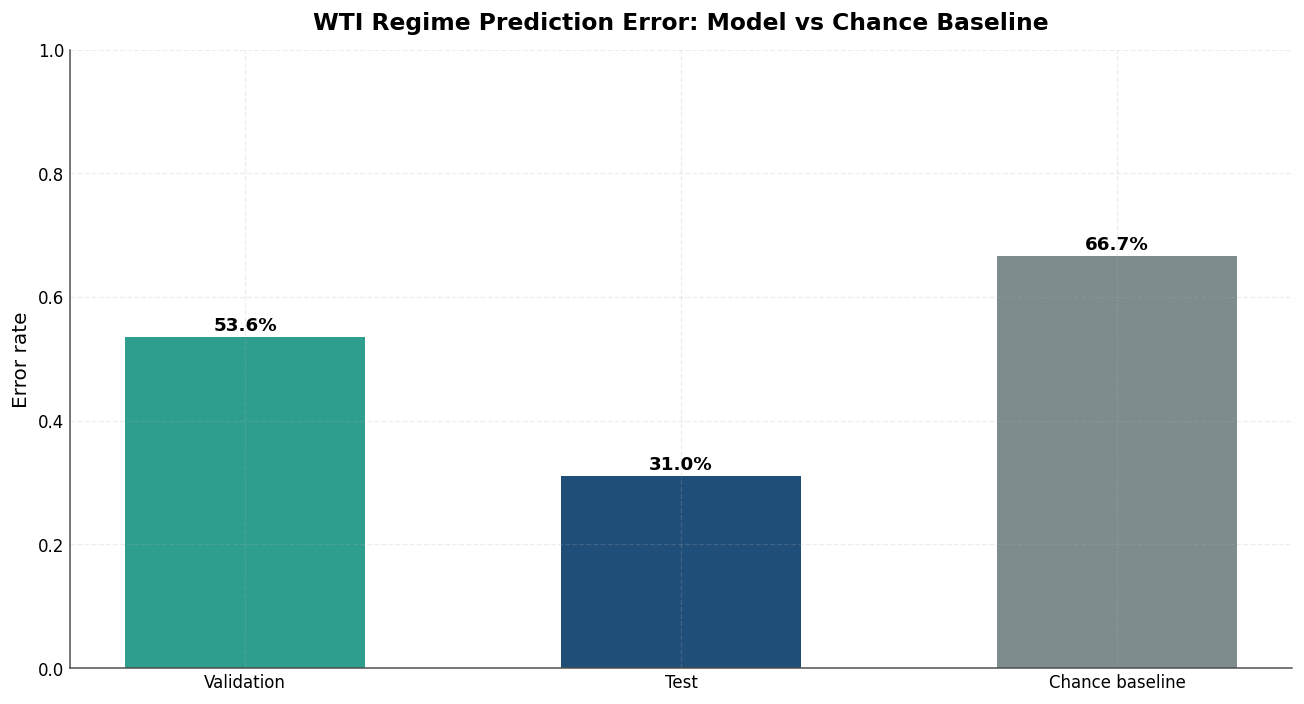

In [26]:
fig, ax = plt.subplots(figsize=FIGSIZE)
bars_x = ["Validation", "Test", "Chance baseline"]
bars_y = [vald_error, test_error, 2 / 3]
bars_c = [C["accent"], C["wti"], C["muted"]]
ax.bar(bars_x, bars_y, color=bars_c, width=0.55)
for i, v in enumerate(bars_y):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
ax.set_ylim(0, 1)
style_axis(ax, "WTI Regime Prediction Error: Model vs Chance Baseline", "", "Error rate")
plt.show()


## Conclusion

In [27]:
summary = """
Conclusion

This notebook implemented the forward, backward, Viterbi, and Baum-Welch
algorithms from scratch and validated them against a known toy example before
applying them to real crude oil and macroeconomic data. Each variable's
monthly time series was transformed into an up/down emission sequence,
a 3-state HMM was trained per variable with Baum-Welch, and the Viterbi
algorithm decoded the most likely bull, bear, and stagnant regime path.
An expert-seeded Hill Climbing search then learned the structure of a belief
network linking these discretised regimes, trained on an 80 percent slice of
the data and evaluated on a held-out 10 percent validation set and a final
10 percent test set. The validation and test error rates should be read
against the chance baseline for three classes, and interpreted alongside the
reference dissertation's own reported error rates on the same task.
"""
print(summary)



Conclusion

This notebook implemented the forward, backward, Viterbi, and Baum-Welch
algorithms from scratch and validated them against a known toy example before
applying them to real crude oil and macroeconomic data. Each variable's
monthly time series was transformed into an up/down emission sequence,
a 3-state HMM was trained per variable with Baum-Welch, and the Viterbi
algorithm decoded the most likely bull, bear, and stagnant regime path.
An expert-seeded Hill Climbing search then learned the structure of a belief
network linking these discretised regimes, trained on an 80 percent slice of
the data and evaluated on a held-out 10 percent validation set and a final
10 percent test set. The validation and test error rates should be read
against the chance baseline for three classes, and interpreted alongside the
reference dissertation's own reported error rates on the same task.

